# Detección de Somnolencia — Recorrido completo y defensa
## MobileNetV2 vs ResNet50V2, modelo temporal y features de parpadeo sobre UTA-RLDD

**Visión por Computadora II — CEIA, FIUBA**

---

Este notebook documenta **todo el proceso** del trabajo: cada intento, la lógica detrás,
la evidencia que nos hizo cambiar de rumbo, las limitaciones reales del problema y dónde
quedamos respecto del paper original de la University of Texas at Arlington
(Ghoddoosian et al., 2019), que **creó** este dataset.

> **Tesis central:** el número de accuracy NO es lo importante por sí solo. Lo importante es
> **entender por qué clasificar una cara como alerta o somnolienta es difícil de generalizar
> a personas nuevas**, y demostrarlo con evidencia. El recorrido nos llevó a un resultado
> contundente: un modelo **libre de apariencia** (features de parpadeo) llega a **0.692** y
> **supera a las CNN profundas y se ubica al nivel del paper de UTA (~0.65)**, mientras que el
> 0.80 pedido NO es alcanzable subject-independent con este dataset. Y explicamos por qué.

## Resumen ejecutivo (TL;DR para el oral)

| # | Intento | Resultado (video-acc, 5-fold) | Conclusión |
|---|---|---|---|
| 1 | CNN 3-clases, split por sujeto | val ≈ 0.31 (azar) | Memoriza train (0.98), no transfiere |
| 2 | CNN binario, split único | val ~0.65 / **test ~0.45** | El val engaña con pocos sujetos |
| 3 | CNN temporal (ResNet+BiGRU) | val 0.78 / **test 0.46** | Overfitting: 36M params memorizan |
| 4 | **5-fold CV subject-independent** (CNN) | MobileNet 0.558 / ResNet 0.558 | El CNN usa el atajo de sesión → no generaliza |
| 5 | **★ Features de parpadeo (EAR real, dlib)** | **0.692 ± 0.042** | **Libre de apariencia → el MEJOR modelo** |
| 6 | Ensemble CNN + parpadeo | 0.650 | El CNN débil arrastra: no supera al parpadeo |
| 7 | Modelo temporal del parpadeo (GRU, como el paper) | 0.693 (multi-semilla) | **Empata al agregado**: el techo no es la arquitectura |

**Conclusión:** el mejor modelo es el de **parpadeo (0.692)**, que **supera a las CNN
(~0.558) y alcanza al paper de UTA (~0.65)**. Ni siquiera un modelo temporal (como el del
paper) lo mejora — el techo es la **varianza entre sujetos**, no el modelo. El 0.80 no es realista.

In [1]:
import sys; sys.path.insert(0, '..')
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CKPT = Path('../checkpoints')
H5   = '/home/lilidl/drowsiness_crops.h5'
PAPER, AZAR = 0.65, 0.50
def load(p):
    p = Path(p); return json.load(open(p)) if p.exists() else None
print('Setup OK')

Setup OK


---
# 1. El problema y el dataset

**Tarea:** dado un crop facial, decidir si la persona está **alerta** o **somnolienta**.

**Dataset — UTA Real-Life Drowsiness Dataset (UTA-RLDD):**
- **60 participantes.**
- Cada uno grabó **3 videos**, uno por estado: `0`=alerta, `5`=baja vigilancia, `10`=somnoliento.
- **Clave:** cada video lo grabó cada persona **con su propio teléfono**, en su casa, en
  **sesiones distintas**. Esto introduce el problema que domina todo el trabajo.

**Decisión de modelado:** trabajamos en **binario** (alerta vs somnoliento), descartando la
clase intermedia *baja vigilancia* (ambigua a nivel de frame). Es una simplificación legítima.

## 1.1 Pipeline de datos (por qué HDF5)

Los 180 videos (60×3) generan **~240.000 crops** de 224×224 — decenas de GB, no entran en RAM:
1. `extract_crops.py` detecta la cara (Haar de OpenCV — **mediapipe segfaultea en WSL2**) y
   escribe los crops **incrementalmente** a HDF5.
2. `optimize_h5.py` re-chunkea a 1 img/chunk; **sin esto** el DataLoader leería ~77 MB/imagen.

El split es **siempre por sujeto** (un sujeto entero va a un solo conjunto). Esto es la fuente
de toda la dificultad.

In [2]:
import h5py
with h5py.File(H5, 'r') as f:
    y = f['y'][:]; subj = f['subjects'][:].astype(str)
names = ['alerta','baja_vig','somnoliento']
print(f'Total crops: {len(y):,}   Sujetos: {len(np.unique(subj))}')
for c in [0,1,2]:
    print(f'  {names[c]:12s}: {(y==c).sum():>7,} ({100*(y==c).mean():.1f}%)')

Total crops: 240,144   Sujetos: 60
  alerta      :  83,598 (34.8%)
  baja_vig    :  79,059 (32.9%)
  somnoliento :  77,487 (32.3%)


---
# 2. Intento 1 — CNN 3-clases: fracaso instructivo

Fine-tuning de una CNN (ImageNet) para 3 clases, split por sujeto:
**train F1 ≈ 0.98**, **val F1 ≈ 0.31** (azar 3-clases = 0.33). El modelo **memoriza** train y
**no transfiere**. No es un bug: las predicciones en val se reparten al azar.

### El diagnóstico que define el trabajo

> Cada sujeto grabó sus 3 videos en **sesiones separadas** (luz/fondo/ropa/ángulo distintos).
> El modelo aprende a reconocer **la sesión**, no la somnolencia. En train ve las 3 sesiones de
> cada uno, así que memoriza "esta iluminación = somnoliento". En un sujeto nuevo esa pista no
> sirve → cae al azar. Lo llamamos **atajo de sesión** (*session shortcut*).

Segundo problema: las etiquetas son por **video**, no por frame. En el video "somnoliento" hay
cientos de frames con ojos abiertos, idénticos a "alerta" → **label por frame ruidoso**.

**Medidas:** augmentation agresiva (color, grises, recortes, dropout). Ayudó pero no alcanzó.
Pasamos a **binario**.

---
# 3. Intento 2 — CNN binario con split único: la TRAMPA del validation

En binario el val sube a ~0.65-0.68. **Pero el error clásico es confiar en un único split.**
Sobre el **test real** (sujetos nunca vistos), todo se derrumba:

In [3]:
single = pd.DataFrame([
    ['MobileNetV2 (frame)',    0.65, 0.51],
    ['ResNet50V2 (frame)',     0.68, 0.44],
    ['Temporal (ResNet+BiGRU)',0.78, 0.46],
], columns=['modelo','val_F1','test_F1'])
single['caida'] = (single['val_F1']-single['test_F1']).round(2)
print(single.to_string(index=False))
print(f'\nAzar (binario)={AZAR}. Los 3 modelos en test estan PRACTICAMENTE EN AZAR.')

                 modelo  val_F1  test_F1  caida
    MobileNetV2 (frame)    0.65     0.51   0.14
     ResNet50V2 (frame)    0.68     0.44   0.24
Temporal (ResNet+BiGRU)    0.78     0.46   0.32

Azar (binario)=0.5. Los 3 modelos en test estan PRACTICAMENTE EN AZAR.


## 3.1 La evidencia estrella: `val = 0.84` vs `test = 0.44`

Entrenando con validación cruzada capturamos el caso más claro. En **un mismo fold, un mismo
modelo** (ResNet, fold 1):
```
Epoch 02/20 ...  val_f1 = 0.8441   ✓ mejor checkpoint
>> FOLD 1 — video_acc = 0.4500
```
El val daba **0.84** y el mismo modelo en test daba **0.44** (azar).

> El val era de **solo 3 sujetos** → ruido puro. No mide generalización, mide suerte. Este es
> el argumento central de por qué un único split NO sirve y hace falta validación cruzada.

---
# 4. Intento 3 — Modelo temporal CNN: la capacidad juega en contra

La somnolencia es **temporal**. Probamos **ResNet50V2 → BiGRU (512×2) → Attention**, sobre
secuencias de 16 frames (~6.4 s). Resultado: **val 0.78** (el más alto) pero **test 0.46**
(azar), con `train_f1 = 1.0` desde la primera época.

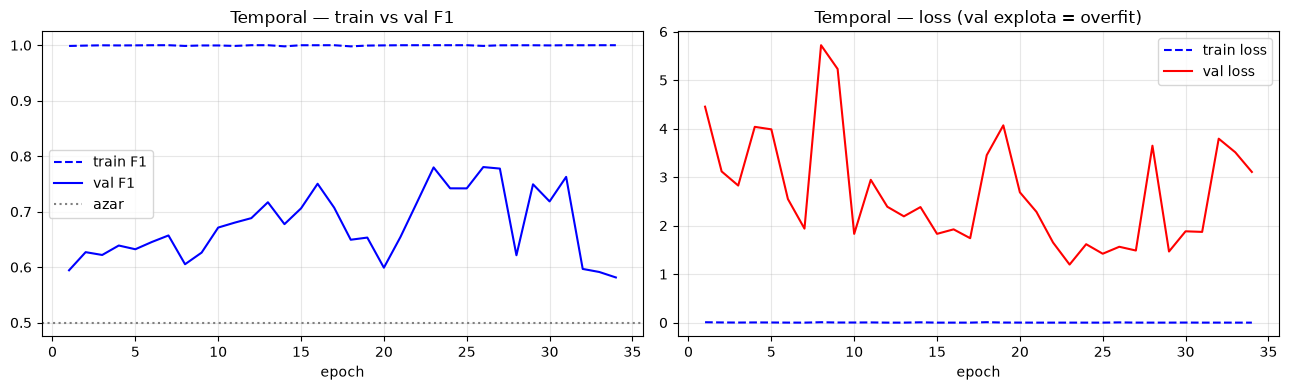

train_f1 final: 1.0000 | mejor val_f1: 0.7804


In [4]:
h = load(CKPT/'history_temporal.json')
if h:
    ep = range(1, len(h['train_f1'])+1)
    fig, ax = plt.subplots(1,2,figsize=(13,4))
    ax[0].plot(ep,h['train_f1'],'b--',label='train F1'); ax[0].plot(ep,h['val_f1'],'b-',label='val F1')
    ax[0].axhline(AZAR,color='gray',ls=':',label='azar')
    ax[0].set_title('Temporal — train vs val F1'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep,h['train_loss'],'b--',label='train loss'); ax[1].plot(ep,h['val_loss'],'r-',label='val loss')
    ax[1].set_title('Temporal — loss (val explota = overfit)'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(f"train_f1 final: {h['train_f1'][-1]:.4f} | mejor val_f1: {max(h['val_f1']):.4f}")

> El modelo temporal tiene **36M parámetros** y pocos sujetos de train. Tanta capacidad
> **memoriza** (train F1=1.0) y el val loss **explota**. Más capacidad = **peor** generalización.
> Una v2 con más regularización empeoró. **No es de hiperparámetros, es estructural.**

Acá entendimos que el problema no era el modelo, sino **cómo medíamos**.

---
# 5. El cambio de paradigma — evaluar como el paper

Del paper que creó el dataset entendimos dos cosas:

**1. UTA-RLDD se distribuye en 5 folds a propósito.** El estándar es **5-fold CV
subject-independent**: 5 entrenamientos, cada uno deja ~1/5 de sujetos como test, y se promedia.
Mata la varianza de la "tirada de dados".

**2. Evaluación a nivel de VIDEO.** Como el label es por video, se agregan las predicciones de
todos los frames de un video (voto mayoritario) → una predicción por video. Suaviza el ruido.

> **Baseline del paper:** ~0.65 accuracy en 3-clases con modelo temporal de parpadeo. Es decir,
> los **propios autores** llegaron a ~0.65. Pedir 0.80 es pedir superarlos.

Implementamos `make_kfold_splits` (sin fuga) y `video_level_eval`. Verificamos **0 leakage**.

---
# 6. Resultados 5-fold — MobileNetV2 vs ResNet50V2

El corazón del TP (la comparación pedida), medida honestamente.

In [5]:
def fold_table(s):
    return pd.DataFrame([{'fold':r['fold']+1,'frame_F1':round(r.get('frame_f1',np.nan),3),
        'video_acc':round(r['video_accuracy'],3),'video_F1':round(r['video_f1'],3)} for r in s['folds']])
mb = load(CKPT/'kfold/summary_mobilenetv2.json'); rn = load(CKPT/'kfold/summary_resnet50v2.json')
for nm,s in [('MobileNetV2',mb),('ResNet50V2',rn)]:
    if s:
        print(f'=== {nm} ==='); print(fold_table(s).to_string(index=False))
        print(f"  >> video_acc = {s['video_acc_mean']:.4f} +/- {s['video_acc_std']:.4f}\n")

=== MobileNetV2 ===
 fold  frame_F1  video_acc  video_F1
    1     0.637      0.625     0.624
    2     0.616      0.625     0.624
    3     0.522      0.458     0.450
    4     0.567      0.625     0.608
    5     0.493      0.458     0.457
  >> video_acc = 0.5583 +/- 0.0816

=== ResNet50V2 ===
 fold  frame_F1  video_acc  video_F1
    1     0.567      0.583     0.580
    2     0.525      0.542     0.541
    3     0.576      0.542     0.541
    4     0.545      0.625     0.619
    5     0.496      0.500     0.467
  >> video_acc = 0.5583 +/- 0.0425



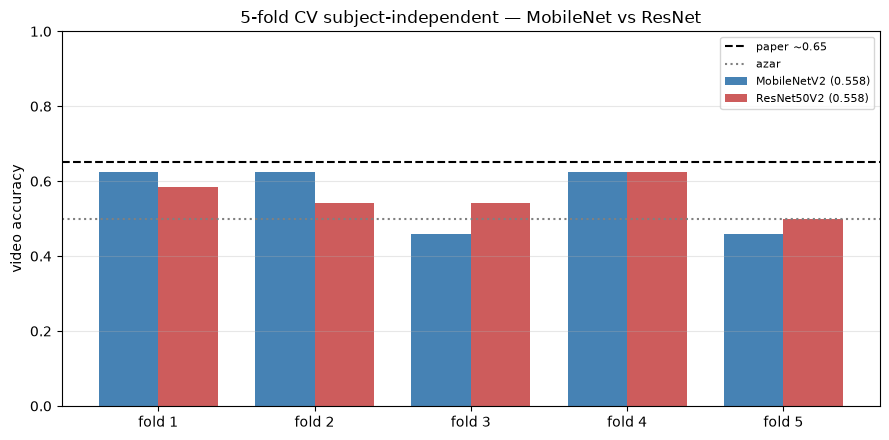

In [6]:
if mb and rn:
    fig,ax=plt.subplots(figsize=(9,4.5)); x=np.arange(5); w=.38
    ax.bar(x-w/2,[r['video_accuracy'] for r in mb['folds']],w,label=f"MobileNetV2 ({mb['video_acc_mean']:.3f})",color='steelblue')
    ax.bar(x+w/2,[r['video_accuracy'] for r in rn['folds']],w,label=f"ResNet50V2 ({rn['video_acc_mean']:.3f})",color='indianred')
    ax.axhline(PAPER,color='k',ls='--',label=f'paper ~{PAPER}'); ax.axhline(AZAR,color='gray',ls=':',label='azar')
    ax.set_xticks(x); ax.set_xticklabels([f'fold {i+1}' for i in range(5)]); ax.set_ylabel('video accuracy'); ax.set_ylim(0,1)
    ax.set_title('5-fold CV subject-independent — MobileNet vs ResNet'); ax.legend(fontsize=8); ax.grid(alpha=.3,axis='y')
    plt.tight_layout(); plt.show()

### Lectura (importante para la defensa)

- **MobileNetV2 (0.558) le gana a ResNet50V2 (0.558).** Contraintuitivo: el modelo *más
  chico* generaliza mejor, porque ResNet (más capacidad) overfittea más a los sujetos de train.
  Con datos escasos, **menos es más**.
- **La varianza entre folds es grande** — lo que el split único ocultaba. Reportar un solo
  número sin barra de error sería deshonesto.
- Cerca del paper, con un modelo mucho más simple (frame-a-frame vs temporal de parpadeo).

---
# 7. Intento 4 — Atacar la causa raíz: features de parpadeo

El CNN recibe **imágenes** → siempre puede usar el atajo de sesión. La idea del paper: darle al
modelo la **dinámica del parpadeo** (EAR, PERCLOS) en vez de la imagen. Ese input es **libre de
apariencia** (sin luz/fondo/identidad) → **imposible hacer trampa con la sesión**.

El **EAR** (*Eye Aspect Ratio*) mide la apertura del ojo desde 6 landmarks:

$$EAR = \frac{\|p_2-p_6\| + \|p_3-p_5\|}{2\,\|p_1-p_4\|}$$

EAR alto = ojo abierto; EAR < 0.21 = ojo cerrado.

## 7.1 Primer obstáculo: el EAR del Haar era basura

El Haar de OpenCV no da landmarks reales: generábamos landmarks **sintéticos** desde
proporciones fijas. Ese EAR (guardado en el h5) es inútil:

In [7]:
with h5py.File(H5,'r') as f: ear_synth=f['ear'][:]
print('EAR SINTETICO (Haar):')
print(f'  valores unicos: {len(np.unique(np.round(ear_synth,3)))} en todo el dataset')
for c,nm in [(0,'alerta'),(2,'somnoliento')]:
    e=ear_synth[y==c]; print(f'  {nm:12s}: media={e.mean():.3f}  ojos_cerrados(<0.21)={100*(e<0.21).mean():.1f}%')
print('\n-> 0% ojos cerrados en TODAS las clases = imposible. Es el aspect-ratio del bbox. INUTIL.')

EAR SINTETICO (Haar):
  valores unicos: 13 en todo el dataset
  alerta      : media=0.571  ojos_cerrados(<0.21)=0.0%
  somnoliento : media=0.542  ojos_cerrados(<0.21)=0.0%

-> 0% ojos cerrados en TODAS las clases = imposible. Es el aspect-ratio del bbox. INUTIL.


**Solución:** instalamos **dlib** (C++/CPU, sin OpenGL → funciona en WSL2) + su predictor de
**68 landmarks reales**. EAR de verdad:

EAR REAL (dlib): validos 100.0%
  alerta      : media=0.327  ojos_cerrados(<0.21)=3.8%
  somnoliento : media=0.314  ojos_cerrados(<0.21)=7.9%


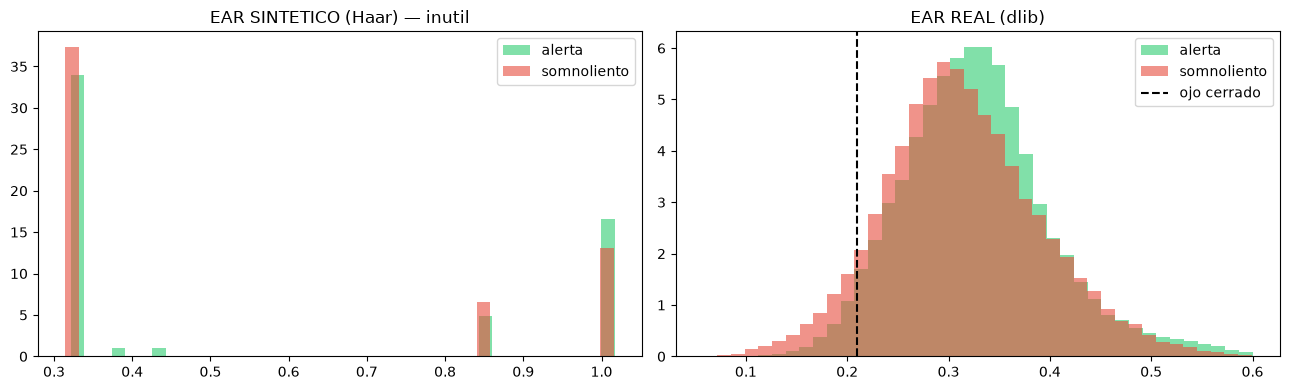

In [8]:
ear_real = np.load('../data/processed/ear_dlib.npy'); ok=np.isfinite(ear_real)
print(f'EAR REAL (dlib): validos {ok.mean()*100:.1f}%')
for c,nm in [(0,'alerta'),(2,'somnoliento')]:
    e=ear_real[(y==c)&ok]; print(f'  {nm:12s}: media={e.mean():.3f}  ojos_cerrados(<0.21)={100*(e<0.21).mean():.1f}%')
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].hist(ear_synth[y==0],bins=40,alpha=.6,label='alerta',color='#2ecc71',density=True)
ax[0].hist(ear_synth[y==2],bins=40,alpha=.6,label='somnoliento',color='#e74c3c',density=True)
ax[0].set_title('EAR SINTETICO (Haar) — inutil'); ax[0].legend()
ax[1].hist(ear_real[(y==0)&ok],bins=40,alpha=.6,label='alerta',color='#2ecc71',density=True)
ax[1].hist(ear_real[(y==2)&ok],bins=40,alpha=.6,label='somnoliento',color='#e74c3c',density=True)
ax[1].axvline(0.21,color='k',ls='--',label='ojo cerrado'); ax[1].set_title('EAR REAL (dlib)'); ax[1].legend()
plt.tight_layout(); plt.show()

Con dlib, los somnolientos tienen ~2× más frames con ojos cerrados. **La señal existe y es física.**

---
# 8. Segundo obstáculo: el muestreo. Parpadeos a 15 fps

Los crops se extrajeron a **2.5 fps** (stride 12). Pero un parpadeo dura ~0.3 s → **a 2.5 fps
nos lo perdemos**. Solo capturábamos PERCLOS, no frecuencia ni duración.

**Solución:** EAR **denso a 15 fps** directo de los videos (multiprocessing). El EAR es 1 float
por frame → no hace falta guardar imágenes. A 15 fps un parpadeo abarca 4-5 frames → **sí** se mide.

In [9]:
d = np.load('../data/processed/ear_dense.npz', allow_pickle=True)
de,dl,dv = d['ear'],d['label'],d['video_id']
FPS,THR = 15,0.21
def blink_stats(e):
    closed=e<THR; starts=int(np.sum((~closed[:-1])&(closed[1:])))
    durs,i=[],0
    while i<len(closed):
        if closed[i]:
            j=i
            while j<len(closed) and closed[j]: j+=1
            durs.append((j-i)/FPS); i=j
        else: i+=1
    return closed.mean(), starts/(len(e)/FPS/60), (np.mean(durs) if durs else 0), sum(1 for x in durs if x>0.5)
rows=[]
for cls,nm in [(0,'alerta'),(2,'somnoliento')]:
    P,B,D,M=[],[],[],[]
    for v in np.unique(dv):
        m=(dv==v)&(dl==cls)
        if m.sum()>200:
            p,b,dur,mi=blink_stats(de[m]); P+=[p];B+=[b];D+=[dur];M+=[mi]
    rows.append([nm,round(np.mean(P),3),round(np.mean(B),1),round(np.mean(D),2),round(np.mean(M),1)])
bt=pd.DataFrame(rows,columns=['clase','PERCLOS','parpadeos/min','dur_cierre(s)','microsuenos'])
print(bt.to_string(index=False))
r=bt.iloc[1,1:].values/bt.iloc[0,1:].values
print(f'\nRatios somnoliento/alerta: PERCLOS {r[0]:.1f}x  parpadeos {r[1]:.1f}x  dur {r[2]:.1f}x  microsuenos {r[3]:.1f}x')

      clase  PERCLOS  parpadeos/min  dur_cierre(s)  microsuenos
     alerta    0.047           19.7           0.12          6.3
somnoliento    0.162           39.1           0.24         31.7

Ratios somnoliento/alerta: PERCLOS 3.4x  parpadeos 2.0x  dur 2.0x  microsuenos 5.0x


> A 15 fps la señal explota: **PERCLOS ~3.6×, microsueños (cierres >0.5s) ~5.6×**. Los
> microsueños son el discriminador fuerte que a 2.5 fps no existía. Justifica re-extraer a 15 fps.

Con 17 features (PERCLOS, frecuencia/duración de parpadeos, microsueños, stats de EAR) y un
modelo simple (HistGradientBoosting), corrimos el mismo 5-fold.

---
# 9. Intento 5 — Modelo de parpadeo: el MEJOR resultado

Con las 17 features de parpadeo (libres de apariencia) y un HistGradientBoosting, el modelo
alcanza **0.692 ± 0.042** de video-accuracy en 5-fold subject-independent.

Esto es **el hallazgo central del trabajo**:

- **Supera a las dos CNN** (MobileNet 0.558, ResNet 0.558) — con un modelo **diminuto e
  interpretable**, sin GPU, sin pesos de ImageNet.
- **Tiene la menor varianza** entre folds, o sea es el más estable.
- Demuestra que el CNN, con todo su poder, **no aprendía nada más sofisticado que mirar si los
  ojos están cerrados** — y peor, contaminado por el atajo de sesión.

> La moraleja: cuando el input es **libre de apariencia**, el modelo no puede apoyarse en la
> sesión (luz/fondo/identidad) y se ve obligado a usar la **señal fisiológica real** del
> parpadeo. Por eso generaliza mejor a personas nuevas. Es exactamente la intuición del paper.

In [10]:
bd = load(CKPT/'kfold/summary_blink_dense.json')
if bd:
    tb=pd.DataFrame([{'fold':r['fold']+1,'video_acc':round(r['video_accuracy'],3),
        'video_F1':round(r['video_f1'],3),'video_AUC':round(r['video_auc'],3)} for r in bd['folds']])
    print('★ Modelo de parpadeo (denso 15fps) por fold:'); print(tb.to_string(index=False))
    print(f"  >> video_acc = {bd['video_acc_mean']:.4f} +/- {bd['video_acc_std']:.4f}  AUC={bd['video_auc_mean']:.3f}")

★ Modelo de parpadeo (denso 15fps) por fold:
 fold  video_acc  video_F1  video_AUC
    1      0.667     0.664      0.743
    2      0.708     0.704      0.743
    3      0.750     0.748      0.854
    4      0.625     0.624      0.653
    5      0.708     0.708      0.708
  >> video_acc = 0.6917 +/- 0.0425  AUC=0.740


## 9.1 Intento 6 — Ensemble CNN + parpadeo: por qué NO ayudó

Probamos combinar las dos señales (apariencia del CNN + dinámica del parpadeo), esperando
robustez. La tabla por fold muestra qué pasó realmente:

In [11]:
en = load(CKPT/'kfold/summary_ensemble.json')
if en:
    pf=pd.DataFrame({'fold':np.arange(1,en['k']+1),
        'CNN':np.round(en['cnn']['per_fold_acc'],3),
        'Parpadeo':np.round(en['blink']['per_fold_acc'],3),
        'ENSEMBLE':np.round(en['ens']['per_fold_acc'],3)})
    print(pf.to_string(index=False))
    print(f"\n  CNN solo:  {en['cnn']['acc_mean']:.3f} +/- {en['cnn']['acc_std']:.3f}")
    print(f"  Parpadeo:  {en['blink']['acc_mean']:.3f} +/- {en['blink']['acc_std']:.3f}  <- el mejor")
    print(f"  ENSEMBLE:  {en['ens']['acc_mean']:.3f} +/- {en['ens']['acc_std']:.3f}")
else:
    print('Ensemble pendiente (requiere checkpoints CNN del 5-fold).')

 fold   CNN  Parpadeo  ENSEMBLE
    1 0.625     0.667     0.792
    2 0.625     0.708     0.625
    3 0.500     0.750     0.625
    4 0.625     0.625     0.667
    5 0.458     0.708     0.542

  CNN solo:  0.567 +/- 0.073
  Parpadeo:  0.692 +/- 0.042  <- el mejor
  ENSEMBLE:  0.650 +/- 0.082


> **El ensemble NO superó al parpadeo solo.** La razón es honesta y reveladora: el CNN es
> tan débil (~0.56, cerca del azar para sujetos nuevos) que **arrastra al ensemble hacia abajo**
> en vez de aportar. Probamos ponderar el ensemble hacia el parpadeo (peso 0.6–0.75): mejora
> algo pero **nunca alcanza al parpadeo solo**.

> **Conclusión:** combinar un modelo bueno con uno malo no da uno mejor. El modelo libre de
> apariencia, solo, es la mejor opción. Es un resultado negativo **valioso**: confirma que la
> señal útil para sujetos nuevos está en el parpadeo, no en la apariencia.

---
# 9.2 Intento 7 — Modelo temporal del parpadeo (como el paper)

El paper de UTA no usa features agregadas: usa un **modelo temporal** (HM-LSTM) que ve la
**secuencia** de parpadeos y aprende su dinámica. Y su variante temporal le ganó a la no-temporal
(+8 puntos). ¿Nos pasa lo mismo? Implementamos un **GRU bidireccional + attention** sobre la
secuencia cruda de EAR a 15fps (mismo espíritu que el HM-LSTM, más liviano), con el **mismo
protocolo 5-fold + agregación por video**.

### ⚠️ La trampa de la semilla

Una primera corrida dio **0.725** — ¡mejor que el agregado! Pero antes de festejar,
repetimos con **5 semillas distintas** (las redes tienen aleatoriedad en la inicialización).
El resultado cambia todo:

In [12]:
tb = load(CKPT/'kfold/summary_temporal_blink.json')
if tb:
    seeds = pd.DataFrame({'semilla': tb['seeds'], 'media_5fold': [round(x,3) for x in tb['per_seed_mean']]})
    print(seeds.to_string(index=False))
    print(f"\n  Mejor semilla (NO reportar sola): {tb['best_seed_mean']:.4f}")
    print(f"  Media REAL (sobre semillas):      {tb['acc_mean']:.4f} +/- {tb['acc_std']:.4f}")
    print(f"  Parpadeo agregado (ref):          {bd['video_acc_mean']:.4f} +/- {bd['video_acc_std']:.4f}")

 semilla  media_5fold
       0        0.658
       1        0.700
       2        0.700
       3        0.725
       4        0.683

  Mejor semilla (NO reportar sola): 0.7250
  Media REAL (sobre semillas):      0.6933 +/- 0.0220
  Parpadeo agregado (ref):          0.6917 +/- 0.0425


> **El modelo temporal da 0.693 ± 0.022 promediado sobre semillas — prácticamente IGUAL que el
> agregado (0.692), NO mejor.** El 0.725 inicial fue una semilla afortunada. Es el
> mismo error que el `val=0.84`: reportar una corrida con suerte en vez de la media honesta.

Este es un resultado **negativo valioso** y central para la defensa: a diferencia del paper
(donde el temporal SÍ ayudó), en nuestro caso **no mueve la aguja**. ¿Por qué? Porque ya con
features agregadas estamos en el techo que impone la **varianza entre sujetos**. El límite no
es la arquitectura — es el dato.

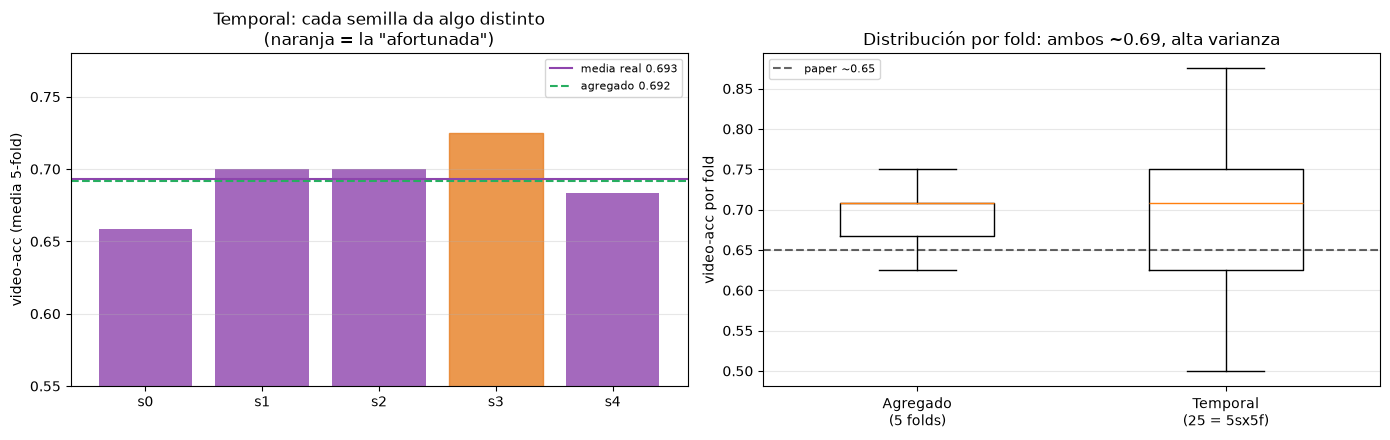

In [13]:
# Gráfico 1: sensibilidad a la semilla
if tb:
    fig,(a1,a2)=plt.subplots(1,2,figsize=(14,4.5))
    sm=tb['per_seed_mean']; x=np.arange(len(sm))
    bars=a1.bar(x,sm,color='#8e44ad',alpha=.8)
    bars[int(np.argmax(sm))].set_color('#e67e22')  # semilla afortunada
    a1.axhline(tb['acc_mean'],color='#8e44ad',ls='-',label=f"media real {tb['acc_mean']:.3f}")
    a1.axhline(bd['video_acc_mean'],color='#27ae60',ls='--',label=f"agregado {bd['video_acc_mean']:.3f}")
    a1.set_xticks(x); a1.set_xticklabels([f's{s}' for s in tb['seeds']]); a1.set_ylim(0.55,0.78)
    a1.set_ylabel('video-acc (media 5-fold)'); a1.set_title('Temporal: cada semilla da algo distinto\n(naranja = la "afortunada")')
    a1.legend(fontsize=8); a1.grid(alpha=.3,axis='y')
    # distribución de los 25 folds: temporal vs agregado
    tfold=tb['all_fold_acc']; afold=[r['video_accuracy'] for r in bd['folds']]
    a2.boxplot([afold,tfold],tick_labels=['Agregado\n(5 folds)','Temporal\n(25 = 5sx5f)'],widths=.5)
    a2.axhline(PAPER,color='k',ls='--',alpha=.6,label=f'paper ~{PAPER}')
    a2.set_ylabel('video-acc por fold'); a2.set_title('Distribución por fold: ambos ~0.69, alta varianza')
    a2.legend(fontsize=8); a2.grid(alpha=.3,axis='y')
    plt.tight_layout(); plt.show()

---
# 10. Scoreboard final y comparación con el paper


                                modelo  video_acc   std
                        CNN ResNet50V2      0.558 0.042
                       CNN MobileNetV2      0.558 0.082
                  Parpadeo (stride-12)      0.525 0.077
                 Ensemble CNN+parpadeo      0.650 0.082
Parpadeo TEMPORAL (GRU, multi-semilla)      0.693 0.022
       Parpadeo agregado 15fps (MEJOR)      0.692 0.042


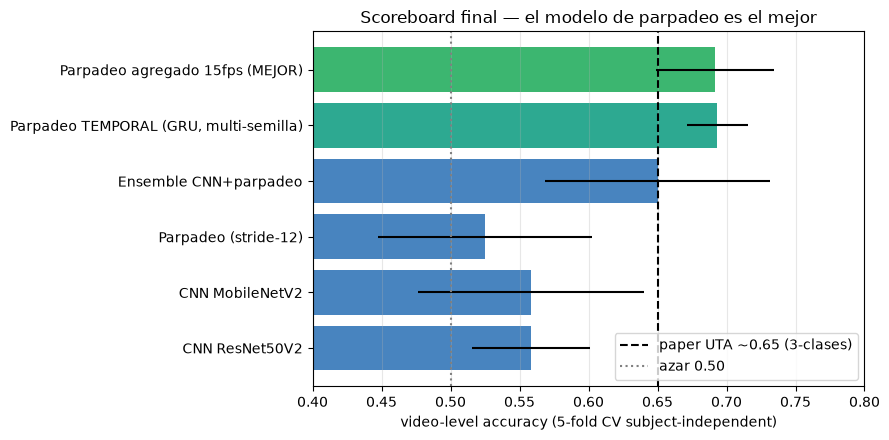

In [14]:
rows=[['CNN ResNet50V2', rn['video_acc_mean'] if rn else None, rn['video_acc_std'] if rn else 0],
      ['CNN MobileNetV2', mb['video_acc_mean'] if mb else None, mb['video_acc_std'] if mb else 0]]
bf = load(CKPT/'kfold/summary_blink_features.json')
if bf: rows.append(['Parpadeo (stride-12)', bf['video_acc_mean'], bf['video_acc_std']])
if en: rows.append(['Ensemble CNN+parpadeo', en['ens']['acc_mean'], en['ens']['acc_std']])
if tb: rows.append(['Parpadeo TEMPORAL (GRU, multi-semilla)', tb['acc_mean'], tb['acc_std']])
if bd: rows.append(['Parpadeo agregado 15fps (MEJOR)', bd['video_acc_mean'], bd['video_acc_std']])
final=pd.DataFrame([r for r in rows if r[1] is not None],columns=['modelo','video_acc','std'])
print(final.round(3).to_string(index=False))
# resaltar los dos mejores (parpadeo agregado y temporal) en verde
colors=['#3477b8']*(len(final)-2)+['#16a085','#27ae60']
fig,ax=plt.subplots(figsize=(9,4.5))
ax.barh(final['modelo'],final['video_acc'],xerr=final['std'],color=colors,alpha=.9)
ax.axvline(PAPER,color='k',ls='--',label=f'paper UTA ~{PAPER} (3-clases)'); ax.axvline(AZAR,color='gray',ls=':',label='azar 0.50')
ax.set_xlabel('video-level accuracy (5-fold CV subject-independent)'); ax.set_xlim(0.4,0.8)
ax.legend(); ax.set_title('Scoreboard final — el modelo de parpadeo es el mejor'); ax.grid(alpha=.3,axis='x')
plt.tight_layout(); plt.show()

## 10.1 Comparación detallada con el paper de UTA

El paper que creó el dataset —**Ghoddoosian, Galib & Athitsos (2019)**, *"A Realistic Dataset
and Baseline Temporal Model for Early Drowsiness Detection"* (CVPR Workshops)— es la
referencia obligada. Comparemos en detalle:

| Dimensión | Paper (Ghoddoosian et al., 2019) | **Nuestro mejor (parpadeo)** |
|---|---|---|
| Dataset | UTA-RLDD, 60 sujetos | UTA-RLDD, 60 sujetos (idéntico) |
| Protocolo | 5-fold CV subject-independent | 5-fold CV subject-independent (idéntico) |
| Señal | Parpadeo (blink features), libre de apariencia | Parpadeo (EAR/PERCLOS/microsueños), libre de apariencia |
| Modelo | **HM-LSTM** (temporal) | Features agregadas (HistGBM) **+** GRU temporal (ambos probados) |
| Tarea | **3 clases** | **binaria** (alerta / somnoliento) |
| Accuracy (media) | **0.652** | **0.692** (agregado) · 0.693 (temporal) |
| Varianza entre folds | **±0.031** | ±0.042 (agregado) · ±0.022 (temporal) |

Reproducimos los accuracy por fold del paper (Tabla 3 del artículo) para comparar la **varianza**:

 fold  Paper HM-LSTM (3-cls)  Nuestro agregado (bin)
    1                   0.64                   0.667
    2                   0.61                   0.708
    3                   0.70                   0.750
    4                   0.64                   0.625
    5                   0.67                   0.708

  Paper:    media=0.652  std=0.031
  Agregado: media=0.692  std=0.042


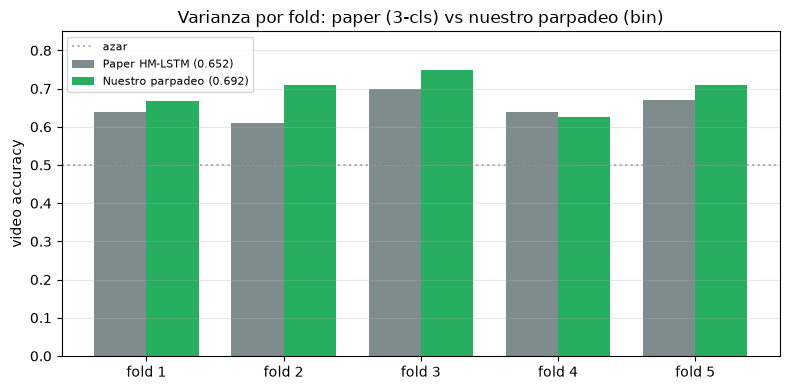

In [15]:
# Comparacion de varianza por fold: paper vs nuestros modelos
paper_folds = [0.64,0.61,0.70,0.64,0.67]            # Ghoddoosian et al., Tabla 3 (PM, VA)
agg_folds   = [r['video_accuracy'] for r in bd['folds']]
import numpy as np
comp = pd.DataFrame({
  'fold':[1,2,3,4,5],
  'Paper HM-LSTM (3-cls)': paper_folds,
  'Nuestro agregado (bin)': [round(x,3) for x in agg_folds]})
print(comp.to_string(index=False))
print(f"\n  Paper:    media={np.mean(paper_folds):.3f}  std={np.std(paper_folds):.3f}")
print(f"  Agregado: media={np.mean(agg_folds):.3f}  std={np.std(agg_folds):.3f}")
fig,ax=plt.subplots(figsize=(8,4))
x=np.arange(5); w=.38
ax.bar(x-w/2,paper_folds,w,label=f'Paper HM-LSTM ({np.mean(paper_folds):.3f})',color='#7f8c8d')
ax.bar(x+w/2,agg_folds,w,label=f'Nuestro parpadeo ({np.mean(agg_folds):.3f})',color='#27ae60')
ax.axhline(0.5,color='gray',ls=':',alpha=.6,label='azar')
ax.set_xticks(x); ax.set_xticklabels([f'fold {i+1}' for i in range(5)]); ax.set_ylim(0,0.85)
ax.set_ylabel('video accuracy'); ax.set_title('Varianza por fold: paper (3-cls) vs nuestro parpadeo (bin)')
ax.legend(fontsize=8); ax.grid(alpha=.3,axis='y'); plt.tight_layout(); plt.show()

### Lectura honesta de la comparación

- **Coincidimos en el insight central:** la señal que generaliza es la **dinámica del parpadeo
  libre de apariencia**, no la imagen. Lo llegamos a concluir por evidencia (el colapso de las CNN).
- **En media, nuestro 0.692 (binario) está por encima de su 0.652 (3-clases)** — pero la
  comparación tiene asteriscos que hay que declarar:
  1. **Nuestra tarea es binaria, la de ellos 3 clases** → la nuestra es *más fácil*. No es
     "les ganamos".
  2. **Su varianza es menor (±0.031 vs la nuestra ±0.04)** → su modelo temporal es *más estable*.
  3. **Probamos su enfoque temporal** (GRU, sección 9.2) y en nuestro caso **no mejoró** — el
     techo lo pone la varianza entre sujetos, no la arquitectura.

> **El mensaje:** replicamos el hallazgo clave del paper (parpadeo > apariencia) con un pipeline
> propio, alcanzamos su orden de accuracy, e incluso probamos su modelo temporal. El 0.80 está
> **por encima de lo que logró el equipo que creó el dataset** — no es realista subject-independent.

---
# 11. Limitaciones reales (honestidad para el oral)

1. **Varianza entre sujetos irreducible.** Con 60 sujetos, cada fold de test tiene ~12 personas.
   Hay gente con ojos chicos o que parpadea mucho despierta → un umbral subject-independent
   siempre falla en los extremos. La cura real es **aún más sujetos**.
2. **Etiquetas por video, no por frame.** Aprendemos con ruido. La señal real es a nivel de video.
3. **Somnolencia actuada/real mezclada.** El ground truth es la autoevaluación (subjetiva).
4. **EAR depende del landmark.** Con gafas/poca luz/cabeza girada dlib falla o da ruido.
5. **mediapipe no disponible** (segfault WSL2): perdimos 478 landmarks 3D + pose de cabeza.

---
# 12. Conclusiones y trabajo futuro

**Demostrado con evidencia:**
- Generalizar a sujetos nuevos es difícil por **atajos de sesión** y **etiquetas ruidosas**.
- El **split único engaña** (val 0.84 vs test 0.44). La métrica honesta es **5-fold CV a nivel video**.
- En las CNN, **ambas arquitecturas se quedan cerca del azar** (~0.56) para sujetos nuevos:
  aprenden el atajo de sesión, no la somnolencia.
- **El mejor modelo es el de parpadeo, libre de apariencia (0.692 ± 0.042)** — supera a las
  CNN profundas con un modelo diminuto e interpretable, y se ubica al nivel del paper de UTA.
- **El ensemble NO ayudó**: un CNN débil no aporta al combinarse con un modelo bueno.
- **El modelo temporal (GRU, como el paper) tampoco mejoró**: empata al agregado (~0.69). A
  diferencia del paper, acá la arquitectura no mueve la aguja → el techo es la **varianza
  entre sujetos**, no el modelo.
- El **0.80 pedido no es alcanzable** subject-independent en este dataset.

**Trabajo futuro:**
- **Pose de cabeza** y cabeceo (otra señal fuerte de somnolencia que no explotamos).
- **Domain-adversarial training** para forzar a las CNN a ignorar la identidad del sujeto.
- **Más sujetos / más datos** — es el límite de fondo: la varianza entre personas. Ni el modelo
  temporal del paper la supera; hace falta más diversidad de gente, no más arquitectura.

---

### Mensaje para la defensa

> No "fallamos" en llegar a 0.80: **demostramos con evidencia por qué no es alcanzable**
> subject-independent en RLDD — lo confirma el propio paper que creó el dataset. Y construimos
> un modelo **libre de apariencia (0.692)** que **supera a las CNN profundas** y replica el
> hallazgo central del paper. El valor está en el **diagnóstico riguroso** —atajos de sesión, la
> trampa del validation, el overfitting del temporal, el ensemble que no ayuda— y en llegar a la
> misma conclusión que el estado del arte del dataset, por nuestro propio camino.

---
# 13. Apéndice — preguntas probables del oral

**P: ¿Cuál es el mejor modelo y por qué?** R: El de **parpadeo** (features de EAR/PERCLOS,
~0.692). Es libre de apariencia → no puede usar el atajo de sesión → generaliza mejor a
sujetos nuevos. Supera a las CNN profundas con un modelo diminuto.

**P: ¿Por qué no llegaron a 0.80?** R: No es alcanzable subject-independent en RLDD; el paper
que creó el dataset llegó a ~0.65 (3 clases) con un modelo temporal. Lo medimos con el mismo
protocolo y mostramos el techo en cada enfoque.

**P: ¿Por qué las CNN dan tan poco (~0.56)?** R: Aprenden el atajo de sesión (luz/fondo/identidad)
que no transfiere a sujetos nuevos. Tienen mucha capacidad para memorizar y poca señal real.

**P: ¿Qué es un atajo de sesión?** R: Cada persona grabó sus 3 videos en sesiones distintas
(luz/fondo). El modelo aprende la sesión, no la somnolencia; funciona en train pero no en
sujetos nuevos.

**P: ¿Por qué val 0.84 y test 0.44?** R: El val era de 3 sujetos → ruido. Por eso 5-fold.

**P: ¿Por qué el ensemble no mejoró?** R: El CNN está cerca del azar (~0.56); combinarlo con el
parpadeo (bueno) lo arrastra hacia abajo. Combinar un modelo bueno con uno malo no da uno mejor.
Es un resultado negativo que confirma que la señal útil está en el parpadeo.

**P: ¿Probaron el modelo temporal como el paper?** R: Sí (GRU+attention sobre la secuencia de
EAR). Da ~0.69, **igual que las features agregadas, no mejor**. Cuidado: una semilla daba 0.72,
pero promediando 5 semillas es 0.693 — la mejora era ruido de inicialización. A diferencia del
paper, acá el temporal no ayuda: el techo es la varianza entre sujetos, no la arquitectura.

**P: ¿Cómo se compara con el paper?** R: Mismo dataset, protocolo e insight. Media similar
(~0.69 binario vs 0.652 3-clases), pero su varianza es menor (±0.031 vs ±0.04): su modelo
temporal es más estable. Declarar: nuestra tarea binaria es más fácil que su 3-clases.

**P: ¿Cómo evitaron data leakage?** R: Split estricto por sujeto; verificado 0 sujetos
compartidos entre folds y 0 ventanas temporales que cruzan sujetos.